# PCA on behavioral measures

In [1]:
import pandas as pd
import numpy as np
import os.path as op
import seaborn as sns
import pingouin
import matplotlib.pyplot as plt

source_folder = '/Users/mrenke/data/ds-dnumrisk/derivatives/phenotype'

df_participants = pd.read_csv(op.join('/Users/mrenke/data/ds-dnumrisk/add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
df_participants = df_participants.loc[:,['subject ID', 'age','group','gender']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
df_participants['group'] = np.where(df_participants['group'] == 0, 'control', 'dyscalc')


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [3]:
math_stuff = pd.read_csv(op.join(source_folder, 'math_skill&confidence&anxiety-means.csv')).set_index('subject')
iq_scores = pd.read_csv(op.join(source_folder, 'iq-scores_ids2.csv')).set_index('subject')

vs_wm = pd.read_csv(op.join(source_folder, 'visio-spatial-WM_CBTtask-params.csv'))
vs_wm.set_index('subject', inplace=True)

panamath_scores = pd.read_csv('/Users/mrenke/data/ds-dnumrisk/add_tables/panamath_AllRunsSummary.csv')
df_pana = panamath_scores.rename(mapper={'Subject ID': 'subject'}, axis=1).set_index('subject')[['Number of Trials','Weber Fraction', 'Percent Correct', 'Number of Non-RT-Outlier Trials']]
df_pana.rename(mapper={'Weber Fraction': 'weber_frac'}, inplace=True, axis=1)
df_pana.drop(999, axis=0, inplace=True)
df_pana.sort_index(inplace=True)

df_comb = df_participants.join([math_stuff, iq_scores, vs_wm, df_pana], how='inner')

In [5]:
df_comb.head()

,age,group,gender,skill_score,anx_mean,conf_mean,me,kn,mean_iq,basisscore,overall_score,erfassungsspanne,Number of Trials,weber_frac,Percent Correct,Number of Non-RT-Outlier Trials
subject,,,,,,,,,,,,,,,,
1,19.0,control,w,36.0,1.333333,2.666667,120.0,105.0,112.5,5,13.0,8,264,0.143232,85.984848,263
2,17.0,dyscalc,w,6.0,2.666667,0.666667,100.0,95.0,97.5,5,10.0,6,264,0.119873,88.257576,259
3,15.0,control,w,29.0,1.666667,3.333333,115.0,95.0,105.0,4,7.0,5,264,0.349204,72.348485,257
4,17.0,dyscalc,w,34.0,4.000000,1.833333,110.0,105.0,107.5,4,7.0,6,264,0.183717,82.196970,257
5,20.0,control,w,30.0,2.000000,2.333333,90.0,115.0,102.5,4,10.0,7,264,0.154192,84.469697,255


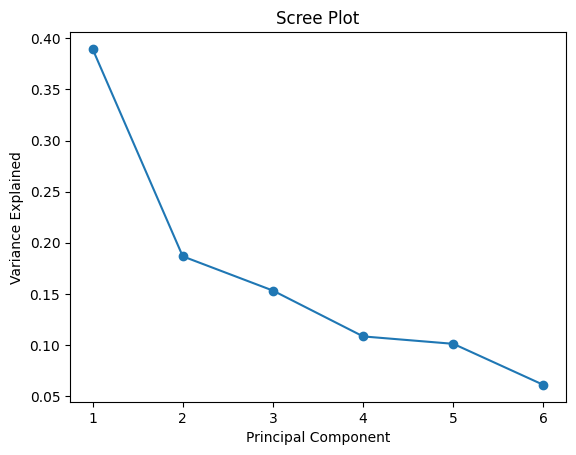

                       PC1       PC2       PC3       PC4       PC5       PC6
skill_score      -0.460046  0.399286  0.080040  0.474364  0.347215  0.526253
erfassungsspanne -0.493328 -0.199037  0.098000 -0.268227  0.639807 -0.475510
basisscore       -0.391423 -0.607248 -0.170390 -0.322334 -0.185482  0.557407
me               -0.413978 -0.192102  0.542656  0.374029 -0.521906 -0.291480
kn               -0.317284  0.620634  0.111636 -0.630902 -0.321560  0.015614
weber_frac        0.346015 -0.100575  0.804996 -0.247383  0.244742  0.317871


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load / select your behavioural data ---
var_of_interest = ['skill_score', 'erfassungsspanne','basisscore', 'me', 'kn', 'weber_frac']
X = df_comb[var_of_interest].dropna()

# --- 2. Standardize (very important for PCA) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. PCA (keep all components initially) ---
pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

# --- 4. Variance Explained ---
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")
plt.show()

# --- 5. Component Loadings (how variables contribute to PCs) ---
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns
)
print(loadings)


In [14]:
# add group info to PCA scores dataframe

df_pca_subs = pd.DataFrame(
    pca_scores,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.index
)   
df_pca_subs = df_pca_subs.join(df_comb[['group']], how='left')

<Axes: xlabel='PC2', ylabel='PC3'>

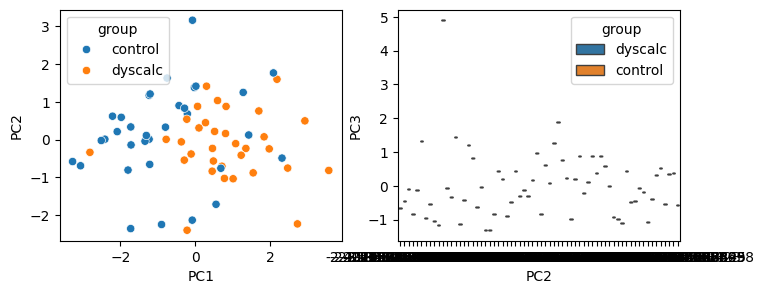

In [18]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
sns.scatterplot(data=df_pca_subs, x='PC1', y='PC2', hue='group', ax=ax[0])
sns.boxplot(data=df_pca_subs,x='PC2', y='PC3', hue='group',ax=ax[1])

In [19]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)


In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X_pca)

# Add cluster labels to the original df
df_clusters = X
df_clusters["cluster"] = clusters


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


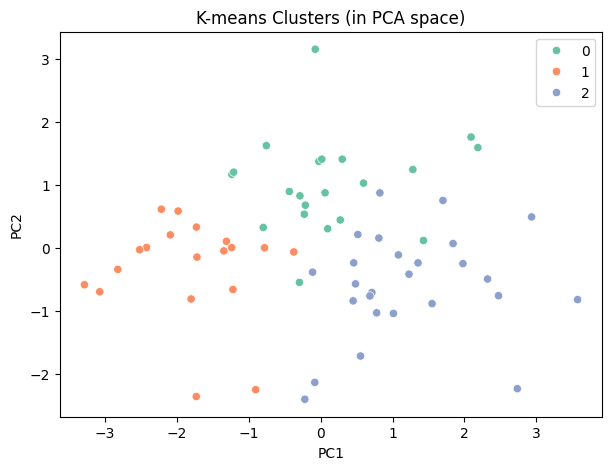

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clusters (in PCA space)")
plt.show()
